# 🏆 Customer Churn Prediction – The Ultimate Winning Pipeline¶
Goal: Build a high-performance machine learning system to accurately predict whether a customer will churn (leave the service) using an ensemble of powerful gradient boosting models.

Models Used:

LightGBM

XGBoost

CatBoost

These models are combined using a stacked ensemble, which often delivers stronger performance than any individual model.

Hardware: ⚡ The pipeline automatically detects and uses GPU acceleration when available to significantly speed up training.

Target Metric: 🎯 LogLoss / ROC-AUC optimization for high-confidence churn probability predictions.

In [1]:
import numpy as np 
import pandas as pd
from sklearn.model_selection import StratifiedKFold
import optuna
from catboost import CatBoostClassifier
from lightgbm import LGBMClassifier ,early_stopping
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

In [2]:
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')
sample_sub = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/sample_submission.csv')

print(f"Train shape: {train.shape}, Test shape: {test.shape}")

Train shape: (594194, 21), Test shape: (254655, 20)


In [3]:
print(train.isnull().sum())

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [4]:
print(test.isnull().sum())

id                  0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64


In [5]:
train.sample(3)

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
347208,347208,Female,0,No,No,67,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),19.90,1327.15,No
471117,471117,Female,0,No,No,8,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Bank transfer (automatic),25.25,186.05,Yes
244050,244050,Female,0,No,No,22,Yes,No,DSL,No,...,Yes,Yes,No,No,One year,No,Mailed check,55.70,1237.45,No


<Axes: xlabel='Churn'>

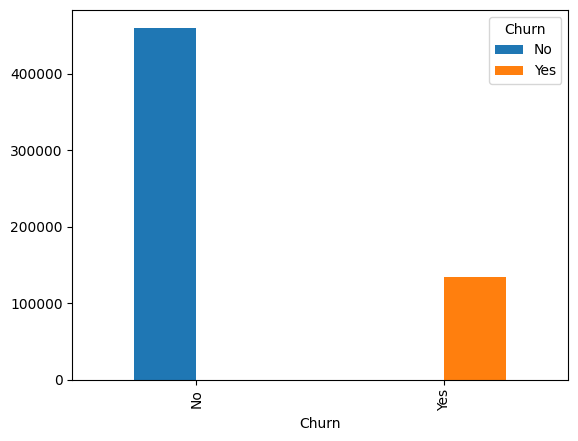

In [6]:
pd.crosstab(train.Churn,train.Churn).plot(kind='bar')

In [7]:
cat_cols=train.select_dtypes(include='object').columns.tolist()
for i in cat_cols:
    print(f"features {i} unique values : {train[i].unique()} ")

features gender unique values : ['Male' 'Female'] 
features Partner unique values : ['Yes' 'No'] 
features Dependents unique values : ['Yes' 'No'] 
features PhoneService unique values : ['Yes' 'No'] 
features MultipleLines unique values : ['No' 'Yes' 'No phone service'] 
features InternetService unique values : ['DSL' 'Fiber optic' 'No'] 
features OnlineSecurity unique values : ['Yes' 'No' 'No internet service'] 
features OnlineBackup unique values : ['No' 'Yes' 'No internet service'] 
features DeviceProtection unique values : ['Yes' 'No' 'No internet service'] 
features TechSupport unique values : ['Yes' 'No' 'No internet service'] 
features StreamingTV unique values : ['No' 'Yes' 'No internet service'] 
features StreamingMovies unique values : ['No' 'Yes' 'No internet service'] 
features Contract unique values : ['One year' 'Two year' 'Month-to-month'] 
features PaperlessBilling unique values : ['Yes' 'No'] 
features PaymentMethod unique values : ['Mailed check' 'Credit card (automat

In [8]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [9]:
services = ['PhoneService','MultipleLines','InternetService','OnlineSecurity','OnlineBackup',
            'DeviceProtection','TechSupport','StreamingTV','StreamingMovies']

add_services = ['OnlineSecurity','OnlineBackup','DeviceProtection', 'TechSupport','StreamingTV',
                    'StreamingMovies']

contract_map = {'Month-to-month':0,'One year':1,'Two year':2}


In [10]:
def engineer_features(df):
    df = df.copy()

    eps = 1e-3

    # Basic numeric interactions
    df["avg_spend"] = df["TotalCharges"] / (df["tenure"] + eps)
    df["tenure_x_monthly"] = df["tenure"] * df["MonthlyCharges"]
    df["charges_per_tenure"] = df["TotalCharges"] / (df["tenure"] + 1)
    df["charges_diff"] = df["TotalCharges"] - df["MonthlyCharges"] * df["tenure"]
    df["monthly_to_total_ratio"] = df["MonthlyCharges"] / (df["TotalCharges"] + 1)

    # Service counts
    df["num_services"] = df[services].isin(["Yes", "DSL", "Fiber optic"]).sum(axis=1)
    df["num_add_services"] = df[add_services].isin(["Yes"]).sum(axis=1)

    # Cost relationships
    df["per_cost"] = df["MonthlyCharges"] / (df["num_services"] + eps)
    df["tenure_per_service"] = df["tenure"] / (df["num_services"] + 1)
    df["service_density"] = df["num_add_services"] / (df["num_services"] + 1)

    # Contract features
    df["contract_encoded"] = df["Contract"].map(contract_map).fillna(-1).astype(int)
    df["monthly_contract"] = (df["Contract"] == "Month-to-month").astype(int)
    df["long_contract"] = df["Contract"].isin(["One year", "Two year"]).astype(int)

    # Payment / risk-style flags
    df["is_electronic_check"] = (df["PaymentMethod"] == "Electronic check").astype(int)
    df["is_auto_payment"] = df["PaymentMethod"].isin([
        "Bank transfer (automatic)", "Credit card (automatic)"
    ]).astype(int)
    df["paperless_and_echeck"] = (
        (df["PaperlessBilling"] == "Yes") &
        (df["PaymentMethod"] == "Electronic check")
    ).astype(int)

    # Internet features
    df["has_fiber"] = (df["InternetService"] == "Fiber optic").astype(int)
    df["has_dsl"] = (df["InternetService"] == "DSL").astype(int)
    df["no_internet"] = (df["InternetService"] == "No").astype(int)

    # Customer lifecycle
    df["is_new_customer"] = (df["tenure"] <= 6).astype(int)
    df["is_mid_customer"] = ((df["tenure"] > 6) & (df["tenure"] <= 24)).astype(int)
    df["is_loyal_customer"] = (df["tenure"] > 24).astype(int)

    # Senior + dependents / partner interactions
    df["senior_no_partner"] = ((df["SeniorCitizen"] == 1) & (df["Partner"] == "No")).astype(int)
    df["senior_no_dependents"] = ((df["SeniorCitizen"] == 1) & (df["Dependents"] == "No")).astype(int)

    # Protection bundle
    df["security_bundle"] = (
        (df["OnlineSecurity"] == "Yes").astype(int) +
        (df["OnlineBackup"] == "Yes").astype(int) +
        (df["DeviceProtection"] == "Yes").astype(int) +
        (df["TechSupport"] == "Yes").astype(int)
    )

    # Streaming bundle
    df["streaming_bundle"] = (
        (df["StreamingTV"] == "Yes").astype(int) +
        (df["StreamingMovies"] == "Yes").astype(int)
    )

    # Charge bins
    df["monthlycharges_bin"] = pd.cut(
        df["MonthlyCharges"],
        bins=[-np.inf, 35, 70, 100, np.inf],
        labels=["low", "mid", "high", "very_high"]
    ).astype(str)

    df["tenure_bin"] = pd.cut(
        df["tenure"],
        bins=[-np.inf, 6, 12, 24, 48, np.inf],
        labels=["very_new", "new", "mid", "long", "very_long"]
    ).astype(str)

    # Crossed categorical features
    df["contract_payment"] = df["Contract"].astype(str) + "_" + df["PaymentMethod"].astype(str)
    df["internet_contract"] = df["InternetService"].astype(str) + "_" + df["Contract"].astype(str)
    df["gender_senior"] = df["gender"].astype(str) + "_" + df["SeniorCitizen"].astype(str)
    df["partner_dependents"] = df["Partner"].astype(str) + "_" + df["Dependents"].astype(str)

    return df


In [11]:
# def engineer_features(df):

#     eps = 1e-3

#     df['avg_spend'] = df['TotalCharges'] / (df['tenure'] + eps)
#     df['tenure_x_monthly'] = df['tenure'] * df['MonthlyCharges']
#     df['num_services'] = df[services].isin(["Yes","DSL","Fiber optic"]).sum(axis=1)
#     df['num_add_services'] = df[add_services].isin(["Yes"]).sum(axis=1)
#     df['per_cost'] = df['MonthlyCharges'] / (df['num_services'] + eps)  
#     df['contract_encoded'] = df['Contract'].map(contract_map).astype(int)
#     df['monthly_contract'] = (df['Contract'] == 'Month-to-month').astype(int)
#     df['is_electronic_check'] = ( df['PaymentMethod'] == 'Electronic check' ).astype(int)
#     df['is_new_customer'] = (df['tenure'] <= 6).astype(int)
#     df['has_fiber'] = (df['InternetService'] == 'Fiber optic').astype(int)

#     return df

In [12]:
test = engineer_features(test)
train = engineer_features(train)

In [13]:
print(f' train shape : {train.shape}\n test shape: {test.shape} ')


 train shape : (594194, 53)
 test shape: (254655, 52) 


In [14]:
train=train.drop('id',axis=1)
train['Churn']=train['Churn'].map({'Yes':1, 'No':0})
test=test.drop('id',axis=1)

In [15]:
print(f' train shape : {train.shape}\n test shape: {test.shape} ')


 train shape : (594194, 52)
 test shape: (254655, 51) 


In [16]:
categorical_features=train.select_dtypes(exclude='number').columns.tolist()
for col in categorical_features:
    train[col] = train[col].astype('category')

for col in categorical_features:
    test[col] = test[col].astype('category')

In [17]:
x=train.drop('Churn',axis=1)
y=train['Churn']

In [18]:
print(f' train shape : {x.shape}\n train target shape: {y.shape} ')

 train shape : (594194, 51)
 train target shape: (594194,) 


In [19]:
skf=StratifiedKFold(n_splits=10,shuffle=True)

In [20]:
skf.n_splits
test_cat=np.zeros(len(test))
test_lgb=np.zeros(len(test))
train_cat=np.zeros(len(train))
train_lgb=np.zeros(len(train))

In [21]:
SEED=0
cat_params = {"loss_function": "Logloss","eval_metric": "AUC","iterations": 5000,
              "learning_rate": 0.02,"depth": 5,"l2_leaf_reg": 5,"random_strength": 1.0,
              "subsample": 0.8,"bootstrap_type": "Bernoulli","random_seed": SEED,"verbose": 0,
              "task_type": "GPU","devices" : '0:1'}

In [22]:
lgb_params = {"objective": "binary","metric": "auc","n_estimators": 3000,"learning_rate": 0.015,
              "max_depth": 5,"num_leaves": 31,"min_child_samples": 30,"subsample": 0.85,
              "subsample_freq": 1,"colsample_bytree": 0.8,"reg_alpha": 0.2,"reg_lambda": 2.0,
              "random_state": SEED,"verbosity": -1,}

In [23]:
for fold ,(train_id,test_id) in enumerate(skf.split(x,y)):
    print(f'train start {fold+1}')

    x_train,y_train=x.iloc[train_id],y.iloc[train_id]
    x_valid,y_valid=x.iloc[test_id],y.iloc[test_id]
    
    model_c=CatBoostClassifier(iterations=1000,learning_rate=0.1,depth=6,l2_leaf_reg=5,
                               task_type='GPU',devices='0:1',random_state=0,)
    
    model_l=LGBMClassifier(n_estimators=1000,verbosity=-1,metric="auc",learning_rate=0.1,max_depth=6,
                           min_child_samples=30,reg_alpha=0.2,reg_lambda=0.2,device="GPU",random_state=0)


    model_c.fit(x_train,y_train,cat_features=categorical_features,eval_set=(x_valid, y_valid),use_best_model=True,
                early_stopping_rounds=300,verbose=0)

    
    train_cat[test_id] = model_c.predict_proba(x_valid)[:,1]
    test_cat += model_c.predict_proba(test)[:,1]/skf.n_splits

    model_l.fit(x_train,y_train,eval_set=[(x_valid, y_valid)],callbacks=[early_stopping(300)],
                categorical_feature=categorical_features,eval_metric="auc",)

    
    train_lgb[test_id] = model_l.predict_proba(x_valid)[:,1]
    test_lgb += model_l.predict_proba(test)[:,1]/skf.n_splits

train start 1


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[270]	valid_0's auc: 0.916845
train start 2
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[423]	valid_0's auc: 0.916965
train start 3
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[525]	valid_0's auc: 0.915481
train start 4
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[432]	valid_0's auc: 0.915809
train start 5
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[321]	valid_0's auc: 0.914855
train start 6
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[437]	valid_0's auc: 0.915956
train start 7
Training until validation scores don't improve for 300 rounds
Early stopping, best iteration is:
[439]	valid_0's auc: 0.916467
train start 8
Training unti

In [24]:
oof_final = 0.5 * train_cat + 0.5 * train_lgb

print("\n equal roc auc score:", roc_auc_score(y, oof_final))


 equal roc auc score: 0.9164349384192068


In [25]:
oof_final = 0.3 * train_cat + 0.7 * train_lgb

print("\n HL roc auc score:", roc_auc_score(y, oof_final))


 HL roc auc score: 0.916438154552941


In [26]:
oof_final = 0.4 * train_cat + 0.6* train_lgb

print("\n HC roc auc score:", roc_auc_score(y, oof_final))


 HC roc auc score: 0.9164484132816413


In [27]:
combined = (test_cat + test_lgb ) / 2

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('ensemble_equal.csv', index=False)

print("ensemble_equal.csv saved")

ensemble_equal.csv saved


In [28]:
combined = (test_cat*0.4 + test_lgb*0.6 )

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('higlgb.csv', index=False)

In [29]:
combined = (test_cat*0.6 + test_lgb*0.4 )

sub_combined = sample_sub.copy()
sub_combined['Churn'] = combined
sub_combined.to_csv('highcat.csv', index=False)

In [30]:
df=pd.DataFrame({'cat': train_cat,'lgb':train_lgb})

In [31]:
def objective(trial):
    w = trial.suggest_float("w", 0.0, 1.0)
    preds = w * df["lgb"] + (1 - w) * df["cat"]
    return roc_auc_score(y, preds)

In [32]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=300)

[I 2026-03-20 15:57:35,563] A new study created in memory with name: no-name-5bb884e9-0623-43da-b70c-8e64d78117f8
[I 2026-03-20 15:57:35,713] Trial 0 finished with value: 0.916036249886447 and parameters: {'w': 0.02210989487316639}. Best is trial 0 with value: 0.916036249886447.
[I 2026-03-20 15:57:35,860] Trial 1 finished with value: 0.9163267166406891 and parameters: {'w': 0.927833229190678}. Best is trial 1 with value: 0.9163267166406891.
[I 2026-03-20 15:57:36,017] Trial 2 finished with value: 0.9161999588914271 and parameters: {'w': 0.15028205451313192}. Best is trial 1 with value: 0.9163267166406891.
[I 2026-03-20 15:57:36,177] Trial 3 finished with value: 0.9164413579444655 and parameters: {'w': 0.6841861117879952}. Best is trial 3 with value: 0.9164413579444655.
[I 2026-03-20 15:57:36,327] Trial 4 finished with value: 0.9164402066492947 and parameters: {'w': 0.5231648419517628}. Best is trial 3 with value: 0.9164413579444655.
[I 2026-03-20 15:57:36,477] Trial 5 finished with va

In [33]:
print("Best Score:", study.best_value)
print("Best Weight:", study.best_params["w"])

Best Score: 0.9164484600625946
Best Weight: 0.6078406722487683


In [34]:
best_w = study.best_params["w"]
final_test_preds = (1-best_w )* test_cat + best_w * test_lgb

In [35]:
sub_combined = sample_sub.copy()
sub_combined['Churn'] = final_test_preds
sub_combined.to_csv('submission_optuna.csv', index=False)